In [ ]:
##June 10,2026

In [2]:
# Import libraries
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Load dataset
df = pd.read_csv(r"C:\Users\jayal\Desktop\attribution_data.csv")

In [4]:
#Analyzing dataset
df.head()

,cookie,time,interaction,conversion,conversion_value,channel
0,00000FkCnDfDDf0iC97iC703B,2018-07-03T13:02:11Z,impression,0,0.0,Instagram
1,00000FkCnDfDDf0iC97iC703B,2018-07-17T19:15:07Z,impression,0,0.0,Online Display
2,00000FkCnDfDDf0iC97iC703B,2018-07-24T15:51:46Z,impression,0,0.0,Online Display
3,00000FkCnDfDDf0iC97iC703B,2018-07-29T07:44:51Z,impression,0,0.0,Online Display
4,0000nACkD9nFkBBDECD3ki00E,2018-07-03T09:44:57Z,impression,0,0.0,Paid Search


In [5]:
df.shape

(586737, 6)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 586737 entries, 0 to 586736
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   cookie            586737 non-null  object 
 1   time              586737 non-null  object 
 2   interaction       586737 non-null  object 
 3   conversion        586737 non-null  int64  
 4   conversion_value  586737 non-null  float64
 5   channel           586737 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 26.9+ MB


In [7]:
df.describe()

,conversion,conversion_value
count,586737.000000,586737.000000
mean,0.030063,0.187871
std,0.170760,1.084498
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,1.000000,8.500000


In [8]:
#Missing value Analysis
df.isnull().sum()

cookie              0
time                0
interaction         0
conversion          0
conversion_value    0
channel             0
dtype: int64

In [8]:
#Duplicate Analysis
df.duplicated().sum()

np.int64(4145)

In [9]:
#Duplicate removal
print("Before removing duplicates:",df.shape)
df = df.drop_duplicates()
print("After removing duplicates:",df.shape)

Before removing duplicates: (586737, 6)
After removing duplicates: (582592, 6)


In [10]:
#Timestamp Standardization
df['time'] = pd.to_datetime(df['time'],utc=True)

In [11]:
df['time'].dtype

datetime64[ns, UTC]

In [ ]:
##June 11,2026

In [12]:
#How many unique users
df['cookie'].nunique()

240108

In [13]:
#How many unique channels
df['channel'].nunique()
df['channel'].value_counts()

channel
Facebook          175068
Paid Search       150666
Online Video      110879
Instagram          75096
Online Display     70883
Name: count, dtype: int64

In [14]:
#Interaction types
df['interaction'].value_counts()

interaction
impression    564953
conversion     17639
Name: count, dtype: int64

In [14]:
#overall conversion rate
df['conversion'].value_counts()
df['conversion'].mean()*100

np.float64(3.0276763155003845)

In [15]:
#conversion rate by channel
df.groupby('channel')['conversion'].mean()*100

channel
Facebook          3.027966
Instagram         2.988175
Online Display    3.017649
Online Video      3.073621
Paid Search       3.017934
Name: conversion, dtype: float64

In [16]:
df.groupby('channel')['conversion_value'].sum()

channel
Facebook          33143.5
Instagram         14039.5
Online Display    13298.5
Online Video      21418.0
Paid Search       28331.5
Name: conversion_value, dtype: float64

In [17]:
df['channel'].value_counts()

channel
Facebook          175068
Paid Search       150666
Online Video      110879
Instagram          75096
Online Display     70883
Name: count, dtype: int64

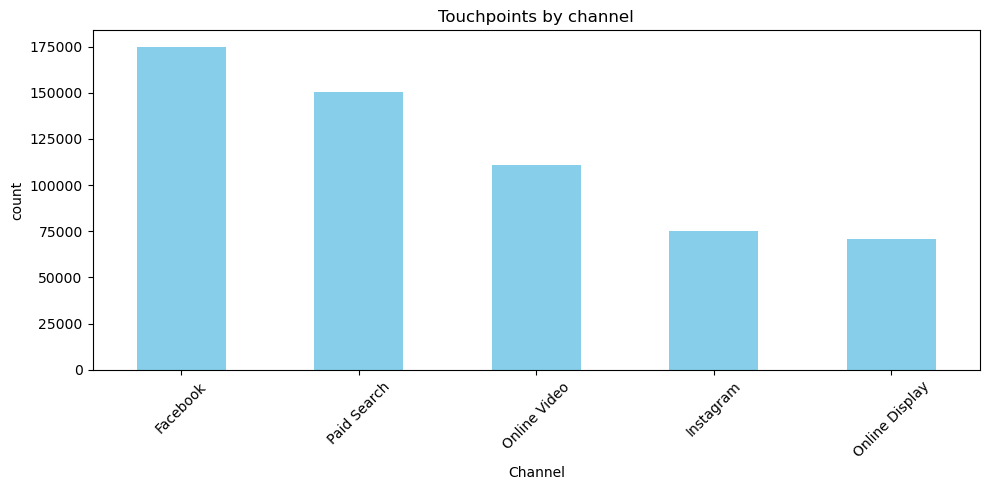

In [18]:
#Touchpoints by channel
plt.figure(figsize=(10,5))
df['channel'].value_counts().plot(kind='bar',color='skyblue')
plt.title("Touchpoints by channel")
plt.xlabel("Channel")
plt.ylabel("count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

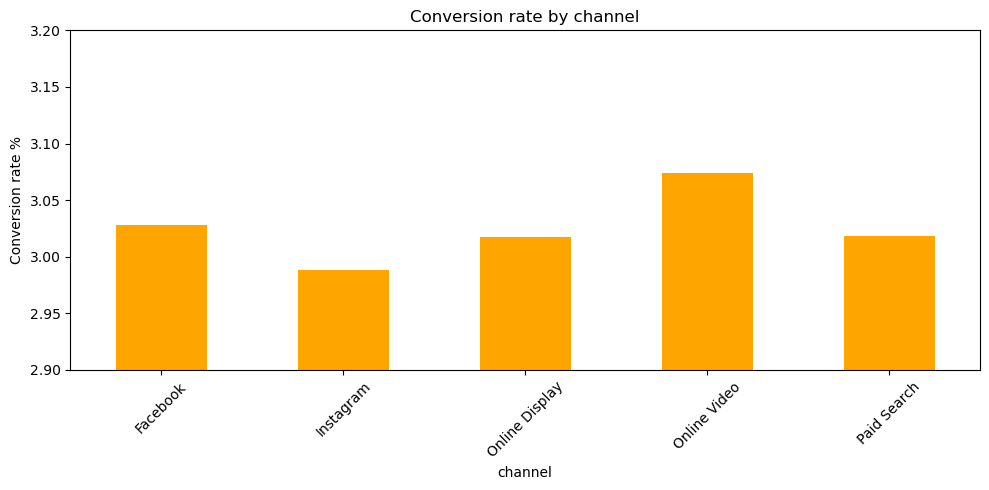

In [19]:
#conversion rate by channel
plt.figure(figsize=(10,5))
conversion_rate=df.groupby('channel')['conversion'].mean()*100
conversion_rate.plot(kind="bar",color="orange")
plt.title("Conversion rate by channel")
plt.xlabel("channel")
plt.ylabel("Conversion rate %")
plt.xticks(rotation=45)
plt.ylim(2.9,3.2)
plt.tight_layout()
plt.show()

Revenue


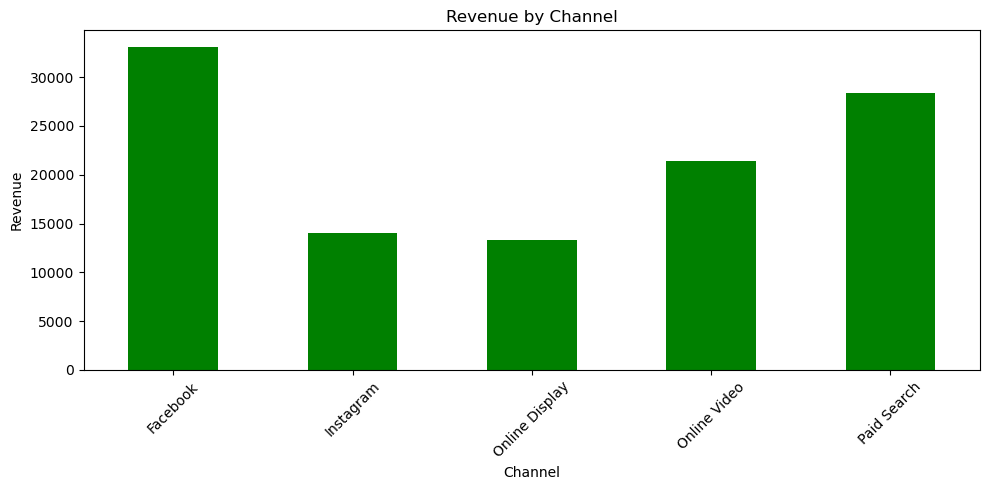

In [20]:
#Revenue by channel
plt.figure(figsize=(10,5))
Revenue_channel=df.groupby('channel')['conversion_value'].sum()

Revenue_channel.plot(kind="bar",color="green")
plt.title("Revenue by Channel")
plt.xlabel("Channel")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
df['channel'].unique()

array(['Instagram', 'Online Display', 'Paid Search', 'Facebook',
       'Online Video'], dtype=object)

In [23]:
df[df['conversion_value']<0]

,cookie,time,interaction,conversion,conversion_value,channel


In [24]:
df['conversion'].unique()

array([0, 1])

In [25]:
df.to_csv("Cleaned_attribution_data.csv",index=False)
print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully


In [26]:
import os
print(os.getcwd())

C:\Users\jayal


In [4]:
#How many touchpoints per user
user_journey = df.groupby('cookie').size().reset_index(name='touchpoints')
print(user_journey.head())
print('Average touchpoints per user:',user_journey['touchpoints'].mean())

                      cookie  touchpoints
0  00000FkCnDfDDf0iC97iC703B            4
1  0000nACkD9nFkBBDECD3ki00E            6
2  0003EfE37E93D0BC03iBhBBhF            5
3  00073CFE3FoFCn70fBhB3kfon            1
4  00079hhBkDF3k3kDkiFi9EFAD            1
Average touchpoints per user: 2.4436378629616673


In [5]:
#which channel appears first most often(First touch)
first_touch = df.sort_values('time').groupby('cookie')['channel'].first()
print(first_touch.value_counts())

channel
Paid Search       76210
Facebook          66848
Online Display    34250
Online Video      34182
Instagram         28618
Name: count, dtype: int64


In [6]:
#which channel appears last most often(last touch)
last_touch = df.sort_values('time').groupby('cookie')['channel'].last()
print(last_touch.value_counts())

channel
Paid Search       71646
Facebook          69111
Online Video      35136
Online Display    34612
Instagram         29603
Name: count, dtype: int64


In [7]:
df.to_csv("Cleaned_attribution_data.csv",index=False)
print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully
